---
title: Radar Vegetation Index
subtitle: Monitor vegetation crop growth using Sentinel-1 GRD data
authors:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-10-28
thumbnail: ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
keywords: ["xarray", "earth observation", "remote sensing"]
tags: ["sentinel-1", "xarray", "land"]
releaseDate: 2025-10-28
datePublished: 2025-10-28
dateModified: 2025-10-28
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

# Radar Vegetation Index

## Table of Contents
1. [Introduction](#IntroductionGRD)
1. [Import modules](#ImportModulesGRD)
2. [File path definition](#PathGRD)
3. [Open the product](#OpenGRD)
4. [Overview of the product content](#OverviewGRD)
5. [Explore product geolocation](#LocationGRD)
6. [Data Decimation](#DecimationGRD)  
7. [Geocoding using GCPs](#GeocodingGRD)  
8. [Geographic selection](#SelectionGRD)
9. [Summary](#SummaryGRD)

(Preface_RVI)=
## Preface

The original notebooks used as a reference for this work are the following:
1. Copernicus Data Space Ecosystem example [available here](https://documentation.dataspace.copernicus.eu/APIs/openEO/openeo-community-examples/python/RVI/RVI.html).
2. Sentinel Hub example, [available here](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/radar_vegetation_index/)

The example has been adapted to use the data provided by the EOPF Zarr Samples project instead of the openEO API or SentinelHub API.

(Introduction_RVI)=
## Introduction

This notebook exmplains how to compute two different vegetation indexes using Sentinel-1 GRD data. They can be used to monitor the vegetation health condition or crop growth using SAR data.  
We will use the Sentinel-1 GRD collection available within the EOPF Sentinel Zarr Samples STAC API, showing how to efficiently retrieve small Areas Of Interest (AOIs) from the data in SAR geometry.

:::{hint} Overview
**Questions**
- How do I efficiently crop Sentinel-1 GRD data?
- What are the possible radar vegetation indexes I can compute?
- How do I create a time series of vegetation indexes based on Sentinel-1 GRD?

**Objectives**
- Being able to slice a Sentinel-1 GRD EOPF Zarr product from an area of interest in lat/lon
- Being able to compute the RVI and RVI4S1 indexes.
:::

(ImportModules_RVI)=
## Import Modules

In [1]:
import pystac_client
import xarray as xr
import numpy as np

xr.set_options(display_expand_attrs=False)

(DataAccess_RVI)=

## Data Access

We use the STAC API to query for the necessary data, specifying also the Sentinel-1 orbit direction.

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
bbox = [
    5.15,
    51.20,
    5.25,
    51.35,
]
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=["2017-05-03", "2017-08-03"],
        query={"sat:orbit_state": dict(eq="ascending")}
    ).items()
)
print(f"items found: {len(items)}")

items found: 37


We can extract the path to the Zarr products from the list of STAC Items

In [4]:
grd_paths = [p.assets["product"].href for p in items]

Open a single product:

In [39]:
dt = xr.open_datatree(grd_paths[0], engine="zarr", chunks="auto")

group_VH = [x for x in dt.children if "VH" in x][0]
grd = dt[group_VH].measurements.to_dataset().rename({"grd":"vh"})

group_VV = [x for x in dt.children if "VV" in x][0]
grd["vv"] = dt[group_VV].measurements.to_dataset().grd
grd

<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 16706, ground_range: 26019)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2017-08-01T17:33:01.279...
  * ground_range  (ground_range) float64 208kB 0.0 10.0 ... 2.602e+05 2.602e+05
    line          (azimuth_time) int64 134kB dask.array<chunksize=(16706,), meta=np.ndarray>
    pixel         (ground_range) int64 208kB dask.array<chunksize=(26019,), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 869MB dask.array<chunksize=(4096, 8192), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 869MB dask.array<chunksize=(4096, 8192), meta=np.ndarray>

(Spatial_Slicing_RVI)=
## Spatial Slicing

Since we want to work on a small area of interest, but the data is not on a regular grid, we will have to understand the data structure to perform the most efficient spatial slicing of the data.  
To perform the spatial slice, we will use Ground Control Points (GCPs).

In [40]:
gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude","longitude"]]
gcps

<xarray.Dataset> Size: 4kB
Dimensions:       (azimuth_time: 10, ground_range: 21)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 80B 2017-08-01T17:33:01.27981...
  * ground_range  (ground_range) float64 168B 0.0 1.301e+04 ... 2.602e+05
    line          (azimuth_time) uint32 40B dask.array<chunksize=(10,), meta=np.ndarray>
    pixel         (ground_range) uint32 84B dask.array<chunksize=(21,), meta=np.ndarray>
Data variables:
    latitude      (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>

As we presented in a previous [notebook](https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-1-l1-grd-zarr-product-exploration/#geocodinggrd), it is possible to interpolate the GCPs data to match the GRD dimensions and assign the latitude and longitude values to the GRD.

We can then create a boolean mask, showing where the coordinates fall within our AOI, which is used to perform the spatial slicing.

**If you have enough resources, this step might take around 1 minute. If not, it might also crash your Python kernel. In the latter case, skip to the next proposed method, which is less resource intensive.**

In [ ]:
%%time

gcp_iterpolated = gcps.interp_like(grd_vh)
grd_vh = grd_vh.assign_coords(
    {"latitude": gcp_iterpolated.latitude, "longitude": gcp_iterpolated.longitude}
)

mask = (
    (gcp_iterpolated.latitude < bbox[3])
    & (gcp_iterpolated.latitude > bbox[1])
    & (gcp_iterpolated.longitude < bbox[2])
    & (gcp_iterpolated.longitude > bbox[0])
)
grd_vh_crop = grd_vh.where(mask.compute(), drop=True)
grd_vh_crop

<xarray.Dataset> Size: 8GB
Dimensions:       (azimuth_time: 16706, ground_range: 26019)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2017-08-01T17:33:01.279...
  * ground_range  (ground_range) float64 208kB 0.0 10.0 ... 2.602e+05 2.602e+05
    line          (azimuth_time) float64 134kB dask.array<chunksize=(16706,), meta=np.ndarray>
    pixel         (ground_range) float64 208kB dask.array<chunksize=(26019,), meta=np.ndarray>
    latitude      (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(16706, 26019), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(16706, 26019), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 869MB dask.array<chunksize=(4096, 8192), meta=np.ndarray>

(Efficient_Spatial_Slicing_RVI)=
## Efficient Spatial Slicing

The previosuly presented procedure is inefficient, since it firsty interpolates the GCPs and then compares each pixel with the coordinates of our AOI.  
We can speed up this process by comparing immediately the low resolution GCPs with our AOI, get the corresponding slice in SAR geometry (using the `azimuth_time` and `ground_range` dimensions).  
Finally interpolate the coordinates only for the smaller extent we extracted.

We firstly define a helper function to compare the dimension of the GCPs subset and get the necessary indexes for spatial slicing:

In [41]:
def build_slice(shape, idx, offset=2):
    """
    Builds two slice objects around a given index, clamped within the shape bounds.

    Parameters
    ----------
    shape : tuple of int
        The dimensions of the array (e.g., (height, width)).
    idx : sequence of tensors or scalars
        The index with two elements.
    offset : int, optional
        The number of elements to include on each side of the index (default is 2).

    Returns
    -------
    list of slice
        A list containing two slice objects for each dimension.
    """
    i0 = int(idx[0].item())
    i1 = int(idx[1].item())

    def clamp_slice(i, dim_size):
        start = max(0, i - offset)
        end = min(dim_size - 1, i + offset)
        return slice(start, end)

    return [clamp_slice(i0, shape[0]), clamp_slice(i1, shape[1])]

We now perform the more efficient spatial slicing:

In [43]:
%%time

grd_vh = dt[group_VH].measurements.to_dataset().rename({"grd":"vh"})

gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude","longitude"]]
mask = (
    (gcps.latitude < bbox[3])
    & (gcps.latitude > bbox[1])
    & (gcps.longitude < bbox[2])
    & (gcps.longitude > bbox[0])
)
idx = np.where(mask==1)
azimuth_time_slice, ground_range_slice = build_slice(mask.shape,idx)

gcps_crop = gcps.isel(dict(azimuth_time=azimuth_time_slice,ground_range=ground_range_slice))

azimuth_time_min = gcps_crop.azimuth_time.min().values
azimuth_time_max = gcps_crop.azimuth_time.max().values

ground_range_min = gcps_crop.ground_range.min().values
ground_range_max = gcps_crop.ground_range.max().values

grd_crop = grd.sel(dict(azimuth_time=slice(azimuth_time_min,azimuth_time_max),ground_range=slice(ground_range_min,ground_range_max)))

gcps_crop_interp = gcps_crop.interp_like(grd_crop)
grd_crop = grd_crop.assign_coords(
    {"latitude": gcps_crop_interp.latitude, "longitude": gcps_crop_interp.longitude}
)
mask_2 = (
    (gcps_crop_interp.latitude < bbox[3])
    & (gcps_crop_interp.latitude > bbox[1])
    & (gcps_crop_interp.longitude < bbox[2])
    & (gcps_crop_interp.longitude > bbox[0])
)
grd_crop = grd_crop.where(mask_2.compute(), drop=True)

grd_crop

CPU times: user 162 ms, sys: 64 ms, total: 226 ms
Wall time: 517 ms


<xarray.Dataset> Size: 10MB
Dimensions:       (azimuth_time: 540, ground_range: 776)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 4kB 2017-08-01T17:33:01.27981...
  * ground_range  (ground_range) float64 6kB 2.205e+05 2.205e+05 ... 2.282e+05
    line          (azimuth_time) float64 4kB 0.0 1.0 2.0 ... 537.0 538.0 539.0
    pixel         (ground_range) float64 6kB 2.205e+04 2.205e+04 ... 2.282e+04
    latitude      (azimuth_time, ground_range) float64 3MB dask.array<chunksize=(540, 776), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 3MB dask.array<chunksize=(540, 776), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) float32 2MB dask.array<chunksize=(540, 776), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 2MB dask.array<chunksize=(540, 776), meta=np.ndarray>

(Geocoding_RVI)=
## Geocoding

### Regular Grid

Since we plan to analyze values from multiple dates as a single datacube, we need to geocode the data on a regular grid to align it and stack it together.  
The following helper function creates a regularly spaced coordinates grid from the lat/lon bounds:

In [44]:
def create_regular_grid(min_x, max_x, min_y, max_y, spatialres):
    """
    Create a regular coordinate grid given bounding box limits.

    Parameters
    ----------
    min_x, max_x : float
        Minimum and maximum X coordinates (e.g., longitude or projected X).
    min_y, max_y : float
        Minimum and maximum Y coordinates (e.g., latitude or projected Y).
    spatialres : float
        Desired spatial resolution (in same units as x/y).

    Returns
    -------
    grid_x_regular : ndarray
        2D array of regularly spaced X coordinates.
    grid_y_regular : ndarray
        2D array of regularly spaced Y coordinates.
    """
    # Ensure positive dimensions and consistent spacing
    width = int(np.ceil((max_x - min_x) / spatialres))
    height = int(np.ceil((max_y - min_y) / spatialres))

    # Compute grid centers (half-pixel offset)
    half_pixel = spatialres / 2.0
    x_regular = np.linspace(min_x + half_pixel, max_x - half_pixel, width, dtype=np.float32)
    y_regular = np.linspace(min_y + half_pixel, max_y - half_pixel, height, dtype=np.float32)
    
    grid_x_regular, grid_y_regular = np.meshgrid(x_regular,y_regular)

    return grid_x_regular, grid_y_regular

### Interpolation

We can now use the `scipy` library to perform the  data interpolation from the irregular to the common regular grid:

In [45]:
%%time

from scipy.interpolate import griddata

grid_lat = grd_crop.latitude.values
grid_lon = grd_crop.longitude.values

grid_x_regular, grid_y_regular = create_regular_grid(np.nanmin(grid_lon), np.nanmax(grid_lon), np.nanmin(grid_lat), np.nanmax(grid_lat), 0.0001)

grid_regular_flat = np.asarray([grid_x_regular.flatten(), grid_y_regular.flatten()]).T
grid_irregular_flat = np.asarray([grid_lon.flatten(), grid_lat.flatten()]).T

interpolated_values_grid_vh = griddata(
    (grid_lon.flatten(), grid_lat.flatten()),
    grd_crop.vh.values.flatten(),
    (grid_x_regular, grid_y_regular),
    method="nearest",
)

interpolated_values_grid_vv = griddata(
    (grid_lon.flatten(), grid_lat.flatten()),
    grd_crop.vv.values.flatten(),
    (grid_x_regular, grid_y_regular),
    method="nearest",
)

ds = xr.Dataset(
    coords=dict(
        y=(['y'], grid_y_regular[:,0]),
        x=(['x'], grid_x_regular[0,:])
    )
)
ds["vh"] = (('y','x'),interpolated_values_grid_vh)
ds["vv"] = (('y','x'),interpolated_values_grid_vv)

CPU times: user 2.03 s, sys: 227 ms, total: 2.26 s
Wall time: 4.06 s


### Visualize Geocoded Result

The gecoded result using the nearest neighbor interpolator contains some artifacts along the borders. We will create a mask to remove them.

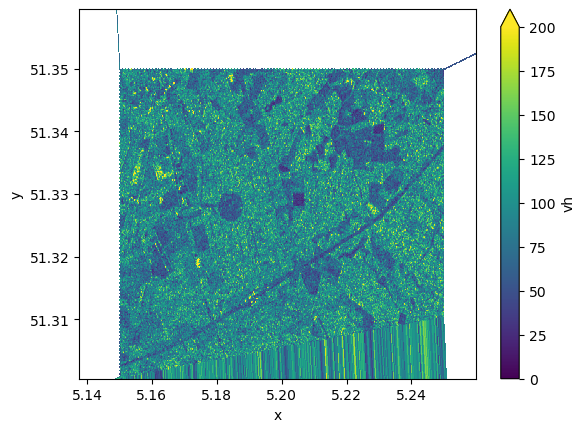

In [50]:
ds.vh.plot.imshow(vmin=0,vmax=200)

Create a mask to remove artifacts and apply it to the data:

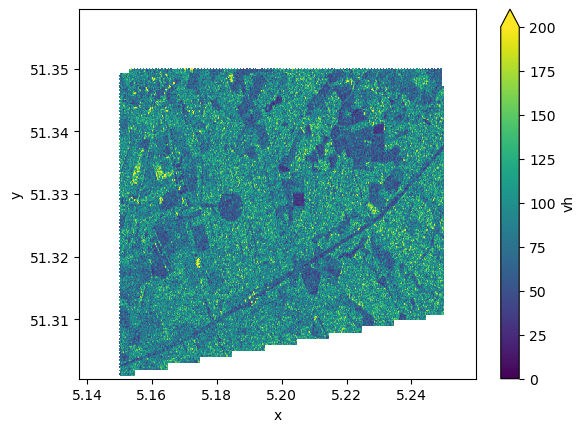

In [51]:
grid_x_regular, grid_y_regular = create_regular_grid(np.nanmin(grid_lon), np.nanmax(grid_lon), np.nanmin(grid_lat), np.nanmax(grid_lat), 0.001)

grid_regular_flat = np.asarray([grid_x_regular.flatten(), grid_y_regular.flatten()]).T
grid_irregular_flat = np.asarray([grid_lon.flatten(), grid_lat.flatten()]).T

interpolated_values_grid_mask = griddata(
    (grid_lon.flatten(), grid_lat.flatten()),
    np.zeros(grd_crop.vh.shape).flatten(),
    (grid_x_regular, grid_y_regular),
    method="linear",
)
mask = xr.DataArray(
    coords=dict(
        y=(['y'], grid_y_regular[:,0]),
        x=(['x'], grid_x_regular[0,:])
    ),
    data=interpolated_values_grid_mask
)
mask_large = mask.interp_like(ds)
ds = ds.where(mask_large==0)

ds.vh.plot.imshow(vmin=0,vmax=200)

(Radar_Vegetation_index_RVI)=
## Radar Vegetation Index

Now that we have our geocoded GRD data, we can compute our vegetation indexes:
1. Radar Vegetation Index (RVI) by [Nasirzadehdizaji et al.](https://www.mdpi.com/2076-3417/9/4/655)

$\frac{4\sigma^0_{VH}}{\sigma^0_{VV}+\sigma^0_{VH}}$

2. Dual-pol Radar Vegetation Index for GRD data (DpRVI) by [Bhogapurapu et al.](https://www.sciencedirect.com/science/article/pii/S0034425722000141) 

In [49]:
lat_vals = grd_vh_crop.latitude.values
lon_vals = grd_vh_crop.longitude.values

In [50]:
print(np.min(lat_vals),np.max(lat_vals))
print(np.min(lon_vals),np.max(lon_vals))

51.30049373148772 51.35955103949565
5.137565566496864 5.25989597673878


In [46]:
lat_vals_large = grd_vh_crop_large.latitude.values
lon_vals_large = grd_vh_crop_large.longitude.values
print(np.min(lat_vals_large),np.max(lat_vals_large))
print(np.min(lon_vals_large),np.max(lon_vals_large))

51.30049373148772 51.35955103949565
5.137565566496864 5.25989597673878


In [13]:
RVI_series = []
RVI4S1_series = []

for grd_path in grd_paths:
    dt = xr.open_datatree(grd_path, engine="zarr", chunks="auto")
    t = np.datetime64(dt.attrs["stac_discovery"]["properties"]["datetime"])
    group_VH = [x for x in dt.children if "VH" in x][0]
    group_VV = [x for x in dt.children if "VV" in x][0]

    grd_vh = dt[group_VH].measurements.to_dataset().rename({"grd":"vh"})
    grd_vv = dt[group_VV].measurements.to_dataset().rename({"grd":"vv"})
    grd = xr.merge([grd_vh,grd_vv])

    gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude","longitude"]]
    mask = (
        (gcps.latitude < bbox[3])
        & (gcps.latitude > bbox[1])
        & (gcps.longitude < bbox[2])
        & (gcps.longitude > bbox[0])
    )
    idx = np.where(mask==1)
    if len(idx[0])==0 or len(idx[1])==0:
        continue
    azimuth_time_slice, ground_range_slice = build_slice(mask.shape,idx)

    gcps_crop = gcps.isel(dict(azimuth_time=azimuth_time_slice,ground_range=ground_range_slice))

    azimuth_time_min = gcps_crop.azimuth_time.min().values
    azimuth_time_max = gcps_crop.azimuth_time.max().values

    ground_range_min = gcps_crop.ground_range.min().values
    ground_range_max = gcps_crop.ground_range.max().values

    grd_crop = grd.sel(dict(azimuth_time=slice(azimuth_time_min,azimuth_time_max),ground_range=slice(ground_range_min,ground_range_max)))

    gcps_crop_interp = gcps_crop.interp_like(grd_crop)
    grd_crop = grd_crop.assign_coords(
        {"latitude": gcps_crop_interp.latitude, "longitude": gcps_crop_interp.longitude}
    )

    RVI = (4 * grd_crop.vh) / (grd_crop.vv + grd_crop.vh)

    q =  grd_crop.vh / grd_crop.vv

    N = q*(q+3)
    D = (q+1)*(q+1)

    RVI4S1 = N/D

    RVI4S1 = RVI4S1.assign_coords(time=t).mean(dim=["azimuth_time","ground_range"]).to_dataset(name="RVI4S1")
    RVI = RVI.assign_coords(time=t).mean(dim=["azimuth_time","ground_range"]).to_dataset(name="RVI")

    # grd_crop = grd_crop.assign_coords(time=t)
    RVI4S1_series.append(RVI4S1)
    RVI_series.append(RVI)

/tmp/ipykernel_4159880/3951949784.py:6: UserWarning: no explicit representation of timezones available for np.datetime64
  t = np.datetime64(dt.attrs["stac_discovery"]["properties"]["datetime"])
/tmp/ipykernel_4159880/3951949784.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  grd = xr.merge([grd_vh,grd_vv])
/tmp/ipykernel_4159880/3951949784.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(

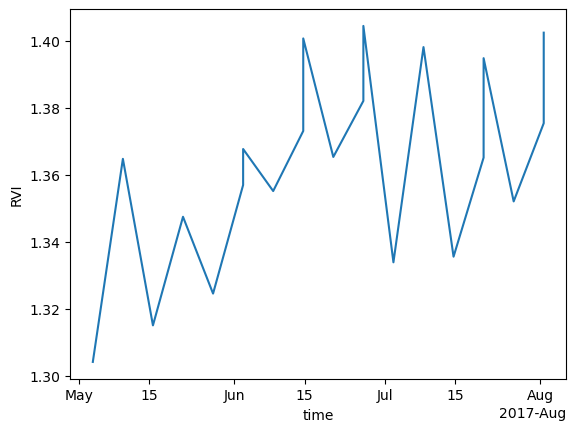

In [17]:
(xr.concat(RVI_series,dim="time").sortby("time").RVI).plot()

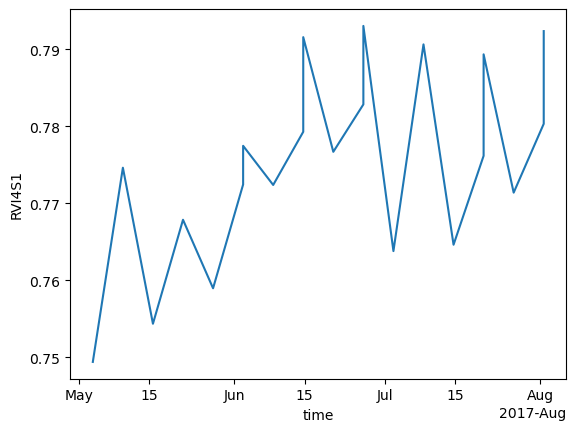

In [12]:
xr.concat(RVI4S1_series,dim="time").sortby("time").RVI4S1.plot()

In [5]:
print(RVI4S1_series[0].vh.values[:3,:3])
print(RVI4S1_series[0].vv.values[:3,:3])
print(RVI4S1_series[0].vh.values[:3,:3] / RVI4S1_series[0].vv.values[:3,:3])
print((RVI4S1_series[0].vh.values / RVI4S1_series[0].vv.values)[:3,:3])
print(np.divide(RVI4S1_series[0].vh,RVI4S1_series[0].vv).values[:3,:3])
print((RVI4S1_series[0].vh / RVI4S1_series[0].vv).values[:3,:3])

AttributeError: 'Dataset' object has no attribute 'vh'

In [113]:
RVI4S1_series[0].vv.values[:3,:3]

array([[187, 222, 171],
       [144, 169, 141],
       [154, 171, 179]], dtype=uint16)

In [117]:
RVI4S1_series[0].vh.values[:3,:3] / RVI4S1_series[0].vv.values[:3,:3]

array([[0.3315508 , 0.44144144, 0.53216374],
       [0.51388889, 0.53254438, 0.4964539 ],
       [0.62987013, 0.66081871, 0.55307263]])

In [116]:
(RVI4S1_series[0].vh / RVI4S1_series[0].vv).values[:3,:3]

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

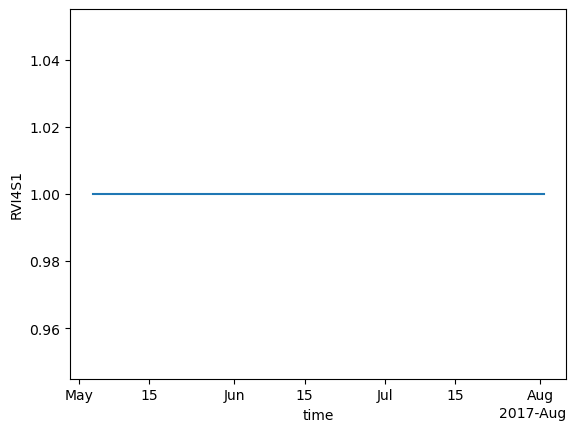

In [101]:
xr.concat(RVI4S1_series,dim="time").sortby("time").RVI4S1.plot()

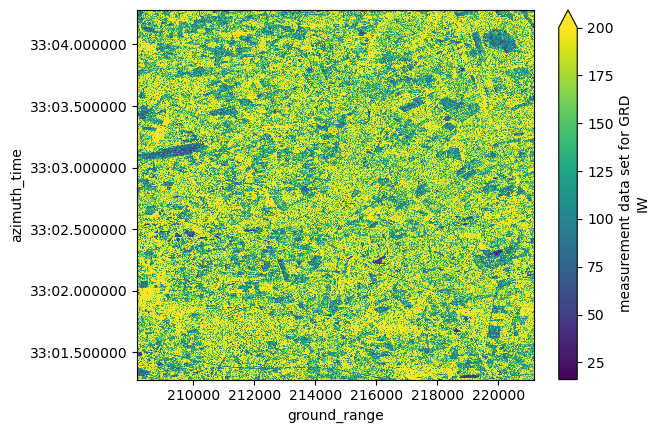

In [83]:
grd_crop.vv.plot.imshow(vmax=200)

ValueError: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>

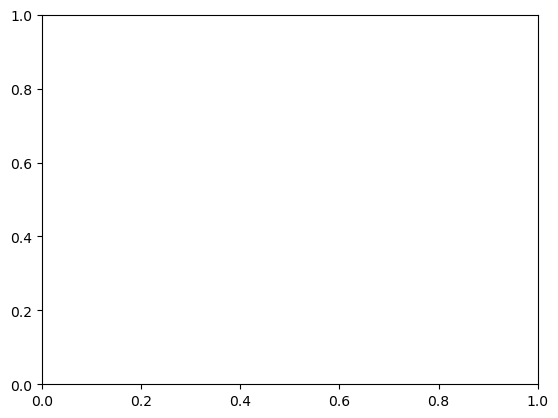

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

grd_crop.vh.plot(
    transform=ccrs.PlateCarree(),
    x="longitude",
    y="latitude",
    vmax=200,
        x="longitude",
    y="latitude",
    vmax=200,
)

In [7]:
gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude","longitude"]]
mask = (
    (gcps.latitude < bbox[3])
    & (gcps.latitude > bbox[1])
    & (gcps.longitude < bbox[2])
    & (gcps.longitude > bbox[0])
)

In [ ]:
def build_slice(shape,idx):
    if idx[0].item(0) == 0:
        idx_00 = 0
        idx_01 = idx[0].item(0) + 2
    elif idx[0].item(0) == shape[0]-1:
        idx_00 = idx[0].item(0) - 2
        idx_01 = idx[0].item(0)
    else:
        idx_00 = idx[0].item(0) - 1
        idx_01 = idx[0].item(0) + 1

    if idx[1].item(0) == 0:
        idx_10 = 0
        idx_11 = idx[1].item(0) + 2
    elif idx[1].item(0) == shape[1]-1:
        idx_10 = idx[1].item(0) - 2
        idx_11 = idx[1].item(0)
    else:
        idx_10 = idx[1].item(0) - 1
        idx_11 = idx[1].item(0) + 1

    return [slice(idx_00,idx_01),slice(idx_10,idx_11)]

azimuth_time_slice, ground_range_slice = build_slice(mask.shape,np.where(mask==1))

gcps_crop = gcps.isel(dict(azimuth_time=azimuth_time_slice,ground_range=ground_range_slice))

azimuth_time_min = gcps_crop.azimuth_time.min().values
azimuth_time_max = gcps_crop.azimuth_time.max().values

ground_range_min = gcps_crop.ground_range.min().values
ground_range_max = gcps_crop.ground_range.max().values

grd_vh.sel(dict(azimuth_time=slice(azimuth_time_min,azimuth_time_max),ground_range=slice(ground_range_min,ground_range_max)))


In [14]:
gcps_crop = gcps.where(mask.compute(), drop=True)

In [18]:
grd_vh.sel(azimuth_time=gcps_crop.azimuth_time)

<xarray.Dataset> Size: 468kB
Dimensions:       (azimuth_time: 1, ground_range: 26019)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 8B 2017-08-01T17:33:01.279817
  * ground_range  (ground_range) float64 208kB 0.0 10.0 ... 2.602e+05 2.602e+05
    line          (azimuth_time) int64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    pixel         (ground_range) int64 208kB dask.array<chunksize=(26019,), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 52kB dask.array<chunksize=(1, 8192), meta=np.ndarray>

In [16]:
gcps_crop.azimuth_time

<xarray.DataArray 'azimuth_time' (azimuth_time: 1)> Size: 8B
array(['2017-08-01T17:33:01.279817000'], dtype='datetime64[ns]')
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 8B 2017-08-01T17:33:01.279817
    line          (azimuth_time) uint32 4B 0

In [11]:
print(mask.azimuth_time.max().values,mask.azimuth_time.min().values)
print(mask.ground_range.max().values,mask.ground_range.min().values)

2017-08-01T17:33:26.277672000 2017-08-01T17:33:01.279817000
260180.0 0.0


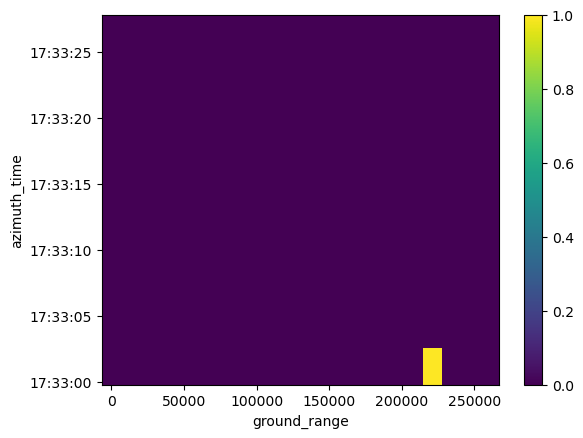

In [9]:
mask.plot.imshow()

In [ ]:

grd_crop = grd.where(mask, drop=True)
mask = None

print(grd_crop.vh.values[:3,:3])
print(grd_crop.vv.values[:3,:3])

a = grd_crop.vh.values[:3,:3]
b = grd_crop.vv.values[:3,:3]

print(a)
print(b)
print(a[0,2])
print(b[0,2])

print(a/b)

In [1]:
import pystac_client
import xarray as xr

xr.set_options(display_expand_attrs=False)

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
bbox = [
    5.15,
    51.20,
    5.25,
    51.35,
]
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=["2017-05-03", "2017-08-03"],
        query={"sat:orbit_state": dict(eq="ascending")}
    ).items()
)
print(f"items found: {len(items)}")

items found: 37


Now that we identified all the STAC Items, we need to extract the products paths from the `href` field:

In [3]:
items[0].assets["product"].href

'https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/cpm_v262/S1A_IW_GRDH_1SDV_20170801T173301_20170801T173326_017733_01DB3B_1E55.zarr'

In [4]:
grd_paths = [p.assets["product"].href for p in items]
grd_paths[0]

'https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/cpm_v262/S1A_IW_GRDH_1SDV_20170801T173301_20170801T173326_017733_01DB3B_1E55.zarr'

In [5]:
import numpy as np
from dask.distributed import Client
from dask.distributed import LocalCluster
import dask


In [6]:

cluster = LocalCluster(n_workers=2)
client = Client(cluster)
client


/home/mclaus@eurac.edu/micromamba/envs/eopf-zarr2/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42129 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42129/status,
Dashboard: http://127.0.0.1:42129/status,Workers: 2
Total threads: 16,Total memory: 62.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43909,Workers: 2
Dashboard: http://127.0.0.1:42129/status,Total threads: 16
Started: Just now,Total memory: 62.80 GiB
Comm: tcp://127.0.0.1:41751,Total threads: 8
Dashboard: http://127.0.0.1:34893/status,Memory: 31.40 GiB
Nanny: tcp://127.0.0.1:43367,


In [15]:
def compute_RVI4S1(grd_path):
    dt = xr.open_datatree(grd_path, engine="zarr", chunks="auto")
    t = np.datetime64(dt.attrs["stac_discovery"]["properties"]["datetime"])
    group_VH = [x for x in dt.children if "VH" in x][0]
    group_VV = [x for x in dt.children if "VV" in x][0]
    print(group_VH)
    print(group_VV)

    grd_vh = dt[group_VH].measurements.to_dataset().rename({"grd":"vh"})
    grd_vv = dt[group_VV].measurements.to_dataset().rename({"grd":"vv"})
    grd = xr.merge([grd_vh,grd_vv])
    gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude","longitude"]].interp_like(grd).compute()
    grd = grd.assign_coords(
        {"latitude": gcps.latitude, "longitude": gcps.longitude}
    )
    mask = (
        (gcps.latitude < bbox[3])
        & (gcps.latitude > bbox[1])
        & (gcps.longitude < bbox[2])
        & (gcps.longitude > bbox[0])
    )

    grd_crop = grd.where(mask, drop=True)
    mask = None
    # q =  grd_crop.vh / grd_crop.vv

    # N = q*(q+3)
    # D = (q+1)*(q+1)

    # RVI4S1 = N/D

    # RVI4S1 = RVI4S1.assign_coords(time=t)
    # RVI4S1.to_zarr("RVI4S1_"+str(t)[]+".zarr")
    return grd_crop

In [16]:
%%time
rvi4s1 = compute_RVI4S1(grd_paths[0])


# delayed_results = [dask.delayed(compute_RVI4S1)(grd_path) for grd_path in grd_paths]
# results = dask.compute(*delayed_results, optimize_graph=False)

# from joblib import Parallel,delayed

# 2 Core
# r1 = Parallel(n_jobs=2)(delayed(compute_RVI4S1)(grd_path) for grd_path in grd_paths)

# Get CRS from STAC item
# datacube = xr.concat(results, dim="time").sortby("time")
# datacube

/tmp/ipykernel_2354399/3135037686.py:3: UserWarning: no explicit representation of timezones available for np.datetime64
  t = np.datetime64(dt.attrs["stac_discovery"]["properties"]["datetime"])


S01SIWGRD_20170801T173301_0025_A101_1E55_01DB3B_VH
S01SIWGRD_20170801T173301_0025_A101_1E55_01DB3B_VV
CPU times: user 2.76 s, sys: 6.75 s, total: 9.5 s
Wall time: 46.7 s


In [17]:
print(rvi4s1.vh.values[:3,:3])
print(rvi4s1.vv.values[:3,:3])

[[115.  92.  54.]
 [137. 113.  87.]
 [138. 129. 110.]]
[[120. 130. 144.]
 [136. 140. 139.]
 [190. 177. 136.]]


In [ ]:
a = rvi4s1.vh.values[:3,:3]
b = rvi4s1.vv.values[:3,:3]

In [ ]:
print(a)
print(b)
print(a[0,2])
print(b[0,2])

[[115.  92.  54.]
 [137. 113.  87.]
 [138. 129. 110.]]
[[115.  92.  54.]
 [137. 113.  87.]
 [138. 129. 110.]]
54.0
54.0


In [11]:
a[0,2] / b[0,2]

np.float32(1.0)

In [12]:
a = rvi4s1.vh.values[:3,:3]
b = rvi4s1.vv.values[:3,:3]
print(a[0,2] / b[0,2])

1.0


In [13]:
a = rvi4s1.vh.values[:3,:3]
b = rvi4s1.vv.values[:3,:3]
print(a[0,2] / b[0,2])

1.0


In [14]:
asd

NameError: name 'asd' is not defined

In [ ]:
b = rvi4s1.vv.values[:3,:3]

In [ ]:
a[0,2] / b[0,2]

np.float32(1.0)

In [ ]:
b[0,2]

np.float32(142.0)

In [ ]:
72/142

0.5070422535211268

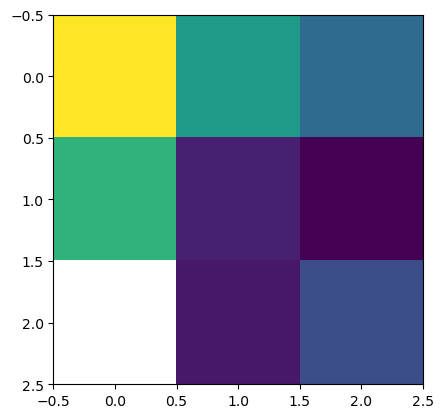

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(a)

In [ ]:
rvi4s1.vv.astype(float).values[:3,:3]

In [ ]:
102

248

In [ ]:
print(rvi4s1.vh.values[0,0])
print(rvi4s1.vv.values[0,0])

102.0
248.0


In [ ]:
rvi4s1.vh.values[0,2] / rvi4s1.vv.values[0,2]

np.float32(1.0)

In [ ]:
np.divide(rvi4s1.vh,rvi4s1.vv).values[:3,:3]

In [ ]:
(rvi4s1.vh/rvi4s1.vv).values[:3,:3]

In [ ]:
q = rvi4s1.vh.astype(float).values - rvi4s1.vv.astype(float).values
q

In [ ]:
print(np.max(q))

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(q)

In [ ]:
q.plot.imshow()

In [ ]:
rvi4s1.vh

In [ ]:
rvi4s1.vv.plot.imshow(vmin=0,vmax=200)

In [ ]:
rvi4s1.plot.imshow()

In [ ]:
r1

In [ ]:
results[0]

In [ ]:
dt = xr.open_datatree(grd_paths[0], engine="zarr", chunks="auto")
dt

In [ ]:
group_VH = [x for x in dt.children if "VH" in x][0]
group_VV = [x for x in dt.children if "VV" in x][0]

grd_vh = dt[group_VH].measurements.to_dataset().rename({"grd":"vh"})
grd_vv = dt[group_VV].measurements.to_dataset().rename({"grd":"vv"})
grd = xr.merge([grd_vh,grd_vv])
gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude","longitude"]].interp_like(grd)
grd = grd.assign_coords(
    {"latitude": gcps.latitude, "longitude": gcps.longitude}
)
mask = (
    (gcps.latitude < bbox[3])
    & (gcps.latitude > bbox[1])
    & (gcps.longitude < bbox[2])
    & (gcps.longitude > bbox[0]).compute()
)

grd_crop = grd.where(mask.compute(), drop=True)

In [ ]:
gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude","longitude"]].interp_like(grd)

In [ ]:
grd = grd.assign_coords(
    {"latitude": gcps.latitude, "longitude": gcps.longitude}
)

In [ ]:
mask = (
    (gcps.latitude < bbox[3])
    & (gcps.latitude > bbox[1])
    & (gcps.longitude < bbox[2])
    & (gcps.longitude > bbox[0]).compute()
)

grd_crop = grd.where(mask.compute(), drop=True)

In [ ]:
from pyproj import Proj, transform
def create_S2grid(grid_lon,grid_lat,spatialres):
    # transformer = Transformer.from_crs("epsg:4326", output_crs)
    # grid_x_irregular,grid_y_irregular = transformer.transform(grid_lat,grid_lon)
    min_x = np.nanmin(grid_lon)
    min_y = np.nanmin(grid_lat)
    grid_lon[grid_lon==np.inf] = 0
    grid_lat[grid_lat==np.inf] = 0
    max_x = np.nanmax(grid_lon)
    max_y = np.nanmax(grid_lat)
    print(f'Irregular grid bounds: {min_x} {min_y} {max_x} {max_y}')
    wout = int((max_x - min_x) / spatialres)
    hout = int((max_y - min_y) / spatialres)
    print(wout,hout)
    half_pixel = spatialres/2
    x_regular = np.linspace(min_x + half_pixel, max_x - half_pixel, int(wout))
    y_regular = np.linspace(min_y - half_pixel, max_y + half_pixel, int(hout))

    return x_regular.astype(np.float32), y_regular.astype(np.float32)


In [ ]:
x_regular, y_regular = create_S2grid(grd_vh_crop.longitude.values,grd_vh_crop.latitude.values,0.0001)
grid_x_regular, grid_y_regular = np.meshgrid(x_regular,y_regular)

grid_x_regular = grid_x_regular.astype(np.float32)
grid_y_regular = grid_y_regular.astype(np.float32)

grid_regular_flat = np.asarray([grid_x_regular.flatten(), grid_y_regular.flatten()]).T
grid_irregular_flat = np.asarray([grd_vh_crop.longitude.values.flatten(), grd_vh_crop.latitude.values.flatten()]).T

from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

delaunay_obj = Delaunay(grid_irregular_flat)
func_nearest = LinearNDInterpolator(delaunay_obj, grd_vh_crop.values.flatten())

In [ ]:
func_nearest(grid_regular_flat)

In [ ]:
grd_vh_crop.values.T

In [ ]:
grd_vh_crop.latitude.values.shape

In [ ]:
grd_vh_crop.values

In [ ]:
grd_vh_crop.latitude.plot.imshow()

In [ ]:
grd_vh_crop.interp(latitude=np.arange(grd_vh_crop.latitude.min().values.item(0), grd_vh_crop.latitude.max().values.item(0), 0.001), longitude=np.arange(grd_vh_crop.longitude.min().values.item(0), grd_vh_crop.longitude.max().values.item(0), 0.001), method="nearest")

In [ ]:
q =  grd_vh_crop / grd_vv_crop

N = q*(q+3)
D = (q+1)*(q+1)

RVI4S1 = N/D

In [ ]:
RVI4S1

Compute sigma0-ellipsioid

In [ ]:
sigma0 = grd_crop / sigma_lut
sigma0

In [ ]:
import numpy as np
sigma_db = (10 * np.log10(sigma0))


In [ ]:

sigma_db.min()

In [ ]:
grd_crop

In [ ]:
grd_crop.plot.imshow(vmin=0,vmax=1000)

In [ ]:
def compute_sigma_from_EOPF_GRD()

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

xr.set_options(display_expand_attrs=False)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

(PathGRD)=
## File path definition

**GRD**: S1A_IW_GRDH_1SDV_20250408T164909_20250408T164934_058668_0743A7_D5AC

**polarization**: VH

```{note}
Please be aware that this notebook works only with Sentinel-1 products converted using eopf-cpm version >= 2.6.0. You can infer the version used by the product URL. Older product versions, like the ones including `cpm_v256` in the URL do not work.
```

In [ ]:
remote_product_path = "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/cpm_v260/S1A_IW_GRDH_1SDV_20250408T164909_20250408T164934_058668_0743A7_D5AC.zarr"

(OpenGRD)=
## Open the product

The GRD product can be opened as a `DataTree` using Xarray:

In [ ]:
dt["S01SIWGRD_20250408T164909_0025_A335_D5AC_0743A7_VH/measurements/grd"]

In [ ]:
dt["S01SIWGRD_20250408T164909_0025_A335_D5AC_0743A7_VH/quality/noise_azimuth"].to_dataset().noise_azimuth_lut[0]

In [ ]:
dt["S01SIWGRD_20250408T164909_0025_A335_D5AC_0743A7_VH/quality/noise_range"]

In [ ]:
dt["S01SIWGRD_20250408T164909_0025_A335_D5AC_0743A7_VH/measurements/grd"]

In [ ]:
dt = xr.open_datatree(remote_product_path, engine="zarr", chunks={})
dt

(OverviewGRD)=
## Overview of the product content

The Zarr GRD product contains one group for each polarization:

In [ ]:
dt.groups[1]

Each polarization group contains the `conditions`, `measurements` and `quality` groups. We can list all the groups for the VH polarization calling `.groups`

In [ ]:
dt[dt.groups[1]].groups

Access now the VH polarization group and the GRD DataArray

In [ ]:
grd = dt[dt.groups[1]]["measurements/grd"]
grd

(LocationGRD)=
## Explore product geolocation

The Zarr product metadata contains information about the product geolocation we can explore in various ways. For instance, we can show the product footprint on an interactive map.

In [ ]:
import geopandas as gpd

# Create a GeoDataFrame from the feature
gdf = gpd.GeoDataFrame.from_features(
    [
        {
            "type": "Feature",
            "geometry": dt.attrs["stac_discovery"][
                "geometry"
            ],  # Use the actual geometry, not the bbox
            "properties": dt.attrs["stac_discovery"][
                "properties"
            ],  # Include all properties
        }
    ],
    crs="EPSG:4326",  # Set the CRS explicitly (adjust EPSG code if needed)
)
gdf.explore()

(DecimationGRD)=
### Data Decimation


We compose a new object, applying decimation to reduce the data we consider for visualization, speeding up the process. Moreover, the original resolution wouldn't fit on most screens. Decimation is performed using the `.isel` xarray method. Here we take one pixel every 10 available in the original dataset:
```python
.isel(x=slice(None, None, 10), y=slice(None, None, 10))
```

In [ ]:
# Decimation data
## decimation
grd_decimated = grd.isel(
    azimuth_time=slice(None, None, 10), ground_range=slice(None, None, 10)
)

## plot
grd_decimated.plot(vmax=200)
plt.show()

(GeocodingGRD)=
## Data Geocoding using GCPs

The data we just visualized is in `azimuth_time` and `ground_range` coordinates. However, if we would like to create a map or compare this data with other data sources, we need to perform a _geocoding_ (also known as _geo-referencing_) operation: the data will be interpolated given the reference Ground Control Points (GCPs). GCPs are defined as points on the surface of the Earth of known location used to interpolate and assig new geographic coordinates to the data.  
If you want to know more about Sentinel-1 Geocoding, please refer to this geocoding guide specific for GRD data: https://asf.alaska.edu/wp-content/uploads/2019/02/GeocodingSentinelData_GDAL_v7.1_.pdf 

**Please not that this geocoding process does not involve terrain correction.** To match the imagery to actual features on the earth and correct for distortions caused by the side-looking geometry of SAR data, you must perform other steps including terrain correction.

We firstly need to access the GCPs data:

In [ ]:
gcp = dt[dt.groups[1]]["conditions/gcp"].to_dataset()
gcp

The GCPs information are provided in a coarser resolution and therefore we need to interpolate them to match the GRD DataArray:

In [ ]:
gcp_iterpolated = gcp.interp_like(grd_decimated)
gcp_iterpolated

Assign the interpolated `latitude` and `longitude` layers to the GRD coordinates:

In [ ]:
grd_decimated = grd_decimated.assign_coords(
    {"latitude": gcp_iterpolated.latitude, "longitude": gcp_iterpolated.longitude}
)

Finally visualize the geocoded data:

In [ ]:
_, ax = plt.subplots(subplot_kw={"projection": ccrs.Miller()}, figsize=(12, 8))
gl = ax.gridlines(
    draw_labels=True, crs=ccrs.PlateCarree(), x_inline=False, y_inline=False
)
grd_decimated.plot(
    ax=ax, transform=ccrs.PlateCarree(), x="longitude", y="latitude", vmax=200
)
ax.set_title("Geocoded Sentinel-1 GRD data")
plt.show()

(SelectionGRD)=
## Geographic Selection

Now that the data is geocoded/georeferenced, it is possible to perform a spatial slicing (or spatial filtering, or cropping) operation, which allows to select only the data falling in our Area Of Interest (AOI):

In [ ]:
lat_max = 40.5
lat_min = 40.25
lon_max = 17
lon_min = 16.5

polygon_lon = [lon_min, lon_max, lon_max, lon_min, lon_min]
polygon_lat = [lat_max, lat_max, lat_min, lat_min, lat_max]

Crop the data in space, defining a boolean mask and applying it to the data:

In [ ]:
mask = (
    (grd_decimated.latitude < lat_max)
    & (grd_decimated.latitude > lat_min)
    & (grd_decimated.longitude < lon_max)
    & (grd_decimated.longitude > lon_min).compute()
)

In [ ]:
grd_crop = grd_decimated.where(mask.compute(), drop=True)

Plot the result in geographic coordinates, highlighting the Area Of Interest:

In [ ]:
_, ax = plt.subplots(subplot_kw={"projection": ccrs.Miller()}, figsize=(12, 8))
gl = ax.gridlines(
    draw_labels=True, crs=ccrs.PlateCarree(), x_inline=False, y_inline=False
)
grd_decimated[::5, ::5].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x="longitude",
    y="latitude",
    vmax=200,
)
plt.plot(
    polygon_lon,
    polygon_lat,
    color="red",
    linewidth=2,
    marker="o",
    transform=ccrs.PlateCarree(),
)
ax.set_title("Geocoded Sentinel-1 GRD data, AOI in red")

_, ax = plt.subplots(subplot_kw={"projection": ccrs.Miller()}, figsize=(12, 8))
gl = ax.gridlines(
    draw_labels=True, crs=ccrs.PlateCarree(), x_inline=False, y_inline=False
)
grd_crop.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x="longitude",
    y="latitude",
    vmax=200,
)
ax.set_title("Cropped Sentinel-1 GRD data")

plt.show()

(SummaryGRD)=
## Summary

This notebook explored Sentinel-1 GRD data: how to open the Zarr product, select specific groups and perform more advanced operations like geocoding.

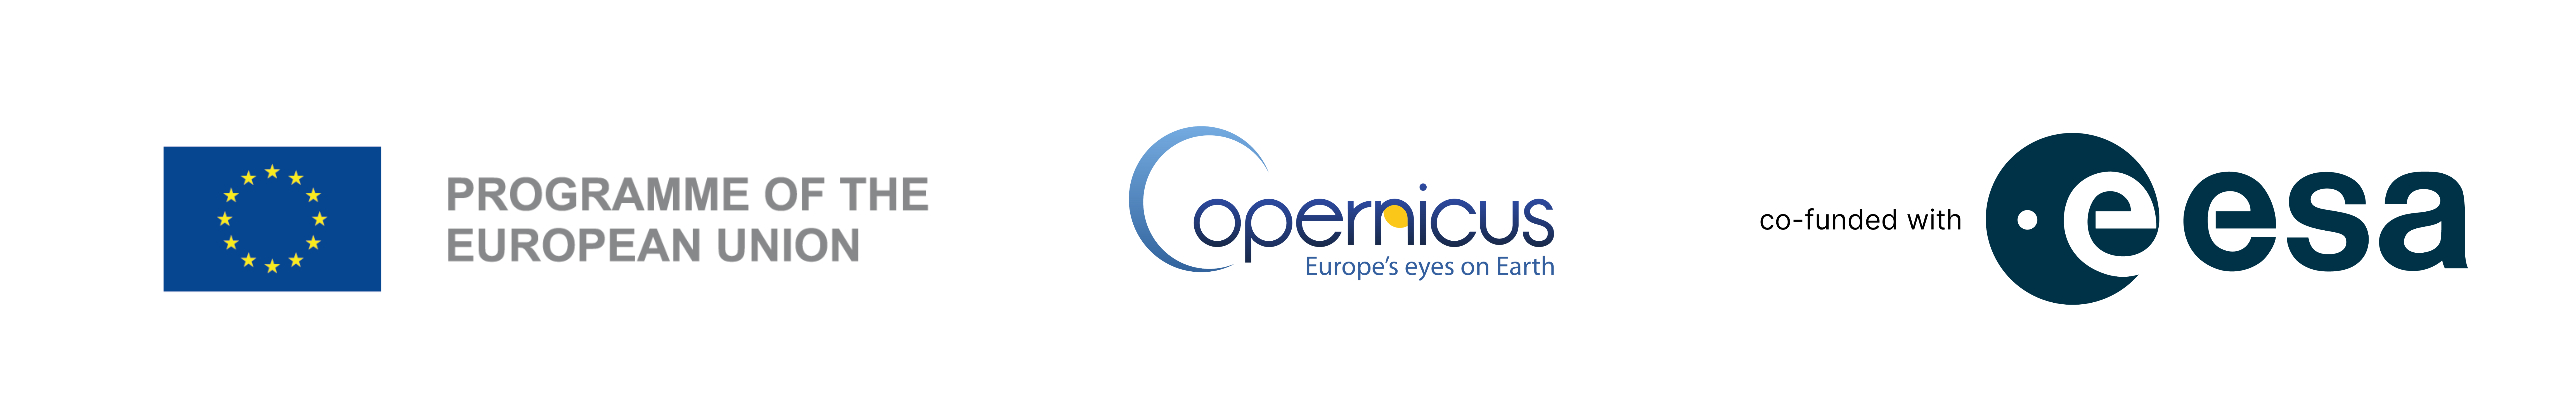